# Analyse Exploratoire des Données (EDA)
Exploration des cycles temporels, de l'impact météorologique et des effets calendaires.

In [314]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

MOIS = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
JOURS_SEMAINE = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

In [315]:
# Chargement des données
df = pd.read_csv('../data/processed/dataset_final.csv')
df['timestamp_paris'] = pd.to_datetime(df['timestamp_paris'], utc=True).dt.tz_convert('Europe/Paris')
df.head()

,timestamp_utc,timestamp_paris,consommation_mw,source_donnee,heure,jour_semaine,mois,annee,saison,covid19,...,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,weekend,nom_ferie,ferie,vacances
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00,56569.0,Données définitives,1,4,1,2016,Hiver,False,...,6.036176,92.699710,141.342131,1.398133,87.926456,0.000000,False,New Year's Day,True,3
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00,55506.5,Données définitives,2,4,1,2016,Hiver,False,...,5.651121,93.667847,145.044523,1.230233,87.187606,0.000000,False,New Year's Day,True,3
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00,52404.0,Données définitives,3,4,1,2016,Hiver,False,...,5.266066,94.635983,148.746916,1.062332,86.448757,0.000000,False,New Year's Day,True,3
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00,49776.0,Données définitives,4,4,1,2016,Hiver,False,...,4.881011,95.604120,152.449308,0.894432,86.546508,0.000000,False,New Year's Day,True,3
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00,48761.0,Données définitives,5,4,1,2016,Hiver,False,...,4.737056,96.119515,167.471301,1.000966,82.983612,0.003004,False,New Year's Day,True,3


In [316]:
df.tail()

,timestamp_utc,timestamp_paris,consommation_mw,source_donnee,heure,jour_semaine,mois,annee,saison,covid19,...,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,weekend,nom_ferie,ferie,vacances
94219,2026-09-30 19:00:00+00:00,2026-09-30 21:00:00+02:00,44329.75,Données temps réel,21,2,9,2026,Automne,False,...,16.505022,80.529951,186.856153,3.528280,97.594697,0.416259,False,NaN,False,0
94220,2026-09-30 20:00:00+00:00,2026-09-30 22:00:00+02:00,43508.75,Données temps réel,22,2,9,2026,Automne,False,...,16.506133,83.211186,180.497148,3.361084,97.594697,0.494731,False,NaN,False,0
94221,2026-09-30 21:00:00+00:00,2026-09-30 23:00:00+02:00,42950.00,Données temps réel,23,2,9,2026,Automne,False,...,16.507243,85.892421,174.138142,3.193888,98.059291,0.573203,False,NaN,False,0
94222,2026-09-30 22:00:00+00:00,2026-10-01 00:00:00+02:00,41006.75,Données temps réel,0,3,10,2026,Automne,False,...,16.184159,85.651284,187.024246,3.223299,98.801464,0.522770,False,NaN,False,0
94223,2026-09-30 23:00:00+00:00,2026-10-01 01:00:00+02:00,38884.75,Données temps réel,1,3,10,2026,Automne,False,...,15.861074,85.410147,199.910350,3.252710,99.046795,0.472337,False,NaN,False,0


## 0. Analyse Descriptive

- Frequence des observations ?

In [317]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94224 entries, 0 to 94223
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype                       
---  ------                                 --------------  -----                       
 0   timestamp_utc                          94224 non-null  str                         
 1   timestamp_paris                        94224 non-null  datetime64[us, Europe/Paris]
 2   consommation_mw                        94224 non-null  float64                     
 3   source_donnee                          94224 non-null  str                         
 4   heure                                  94224 non-null  int64                       
 5   jour_semaine                           94224 non-null  int64                       
 6   mois                                   94224 non-null  int64                       
 7   annee                                  94224 non-null  int64                       
 8   saison 

In [318]:
df.describe()

,consommation_mw,heure,jour_semaine,mois,annee,temperature_c,temperature_point_rosee_c,humidite_pct,vent_direction_deg,vent_vitesse_ms,nebulosite,precip_1h_mm,temperature_c_pondere_pop,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,vacances
count,94224.000000,94224.000000,94224.000000,94224.000000,94224.000000,94117.000000,94117.000000,94117.000000,94117.000000,94117.000000,93763.000000,94059.000000,94117.000000,94117.000000,94117.000000,94117.000000,94117.000000,93763.000000,94059.000000,94224.000000
mean,52158.201138,11.499989,2.999958,6.418641,2020.882174,13.734622,8.668403,74.614965,188.862736,3.203782,81.117666,0.072721,13.586453,8.361766,73.983477,194.135836,3.247108,76.891669,0.073664,1.034927
std,11400.166005,6.922239,2.000239,3.417064,3.104189,7.030407,4.996480,14.215062,50.062162,1.340269,22.062744,0.158232,7.189403,5.048673,14.961883,52.651983,1.412013,24.289444,0.175096,1.317078
min,29364.500000,0.000000,0.000000,1.000000,2016.000000,-5.876923,-12.630769,23.384615,33.076923,0.307692,0.000000,0.000000,-6.633710,-14.014853,19.972188,33.215159,0.235636,0.000000,0.000000,0.000000
25%,43609.375000,5.750000,1.000000,3.000000,2018.000000,8.428205,4.987179,65.384615,151.538462,2.205128,76.666667,0.000000,8.188325,4.677893,64.321210,154.990831,2.208435,68.238336,0.000000,0.000000
50%,50312.000000,11.500000,3.000000,6.000000,2021.000000,13.153846,8.838462,77.974359,189.230769,3.000000,89.166667,0.002564,13.030532,8.538233,77.499083,194.104523,3.049817,85.734649,0.000102,0.000000
75%,59694.125000,17.250000,5.000000,9.000000,2024.000000,18.789744,12.812821,85.923077,225.897436,4.000000,95.238095,0.074359,18.729686,12.528475,85.871129,233.059291,4.083639,94.435384,0.066779,3.000000
max,96129.500000,23.000000,6.000000,12.000000,2026.000000,37.684615,20.853846,98.461538,332.307692,11.446154,100.982456,4.730769,38.151345,20.666870,98.804401,340.849633,11.461247,100.982456,7.612317,3.000000


In [319]:
valeurs_manquantes = df.isna().sum()
valeurs_manquantes = valeurs_manquantes[valeurs_manquantes > 0]

print("Nombre de valeurs manquantes par colonne :")
print(valeurs_manquantes)

nombre_doublons = df["timestamp_paris"].duplicated().sum()
print(f"\nNombre de timestamps en doublon : {nombre_doublons}")

ecart = df["timestamp_paris"].diff()
print("\nIntervalles :")
print(ecart.value_counts())

Nombre de valeurs manquantes par colonne :
temperature_c                              107
temperature_point_rosee_c                  107
humidite_pct                               107
vent_direction_deg                         107
vent_vitesse_ms                            107
nebulosite                                 461
precip_1h_mm                               165
temperature_c_pondere_pop                  107
temperature_point_rosee_c_pondere_pop      107
humidite_pct_pondere_pop                   107
vent_direction_deg_pondere_pop             107
vent_vitesse_ms_pondere_pop                107
nebulosite_pondere_pop                     461
precip_1h_mm_pondere_pop                   165
nom_ferie                                91393
dtype: int64

Nombre de timestamps en doublon : 0

Intervalles :
timestamp_paris
0 days 01:00:00    94223
Name: count, dtype: int64


In [320]:
print("Consommation minimale :")
print(df.loc[df["consommation_mw"].idxmin()])

print("\nConsommation maximale :")
print(df.loc[df["consommation_mw"].idxmax()])

Consommation minimale :
timestamp_utc                            2020-05-10 05:00:00+00:00
timestamp_paris                          2020-05-10 07:00:00+02:00
consommation_mw                                            29364.5
source_donnee                                  Données définitives
heure                                                            7
jour_semaine                                                     6
mois                                                             5
annee                                                         2020
saison                                                   Printemps
covid19                                                       True
temperature_c                                            15.525641
temperature_point_rosee_c                                13.774359
humidite_pct                                             89.717949
vent_direction_deg                                      162.307692
vent_vitesse_ms                       

## 1. Analyse Séries Temporelles

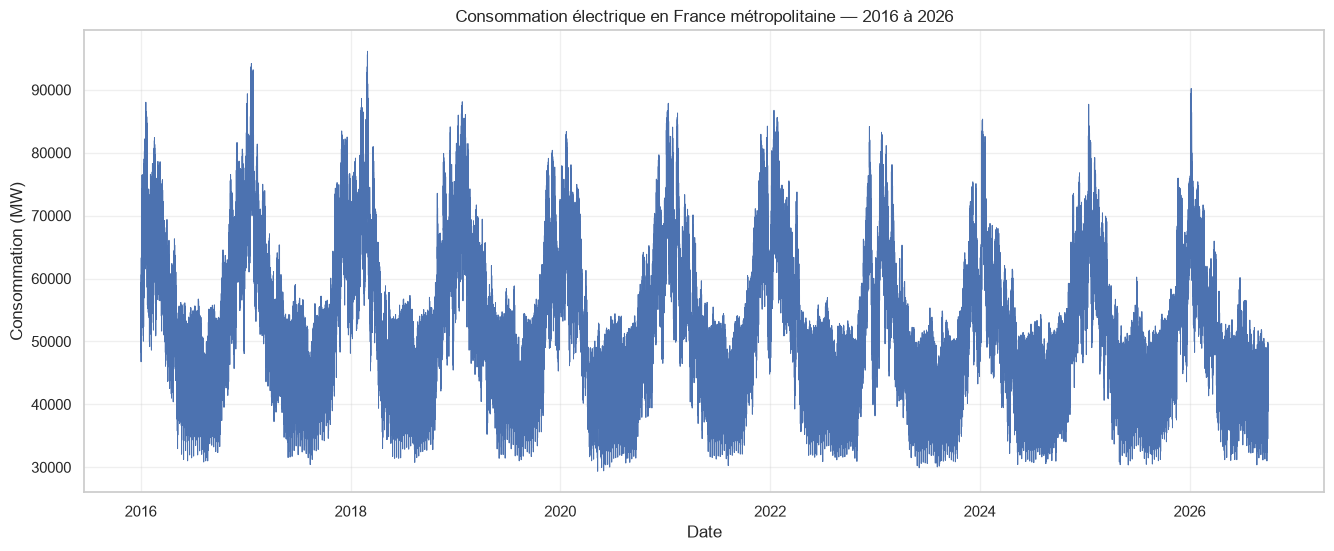

In [321]:
plt.figure(figsize=(16, 6))
plt.plot(
    df["timestamp_paris"],
    df["consommation_mw"],
    linewidth=0.7
)

plt.title("Consommation électrique en France métropolitaine — 2016 à 2026")
plt.xlabel("Date")
plt.ylabel("Consommation (MW)")
plt.grid(True, alpha=0.3)
plt.show()

### 1.1 Cycle Annuel

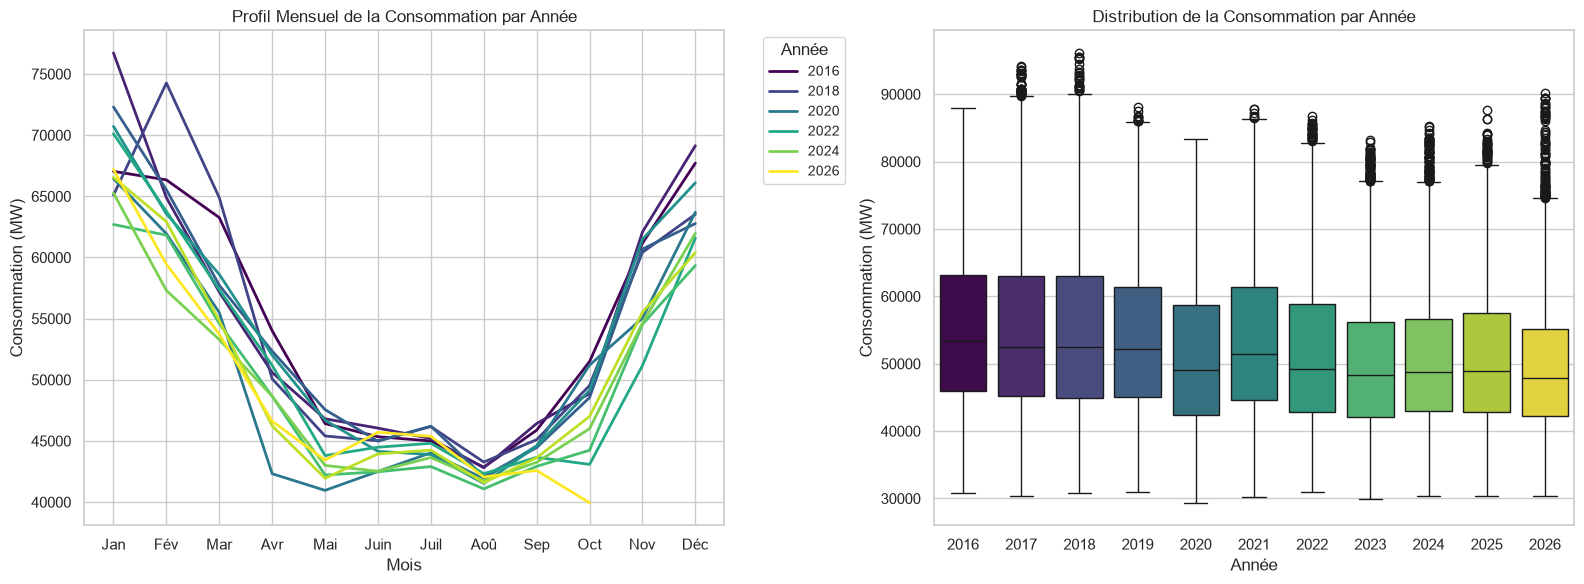

In [322]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=df, x='mois', y='consommation_mw', hue='annee', ax=axes[0], palette="viridis", errorbar=None, linewidth=2)
axes[0].set_title("Profil Mensuel de la Consommation par Année")
axes[0].set_xlabel("Mois")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(MOIS)
axes[0].set_ylabel("Consommation (MW)")
axes[0].legend(title="Année", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

sns.boxplot(data=df, x='annee', y='consommation_mw', ax=axes[1], hue='annee', palette="viridis", legend=False)
axes[1].set_title("Distribution de la Consommation par Année")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()


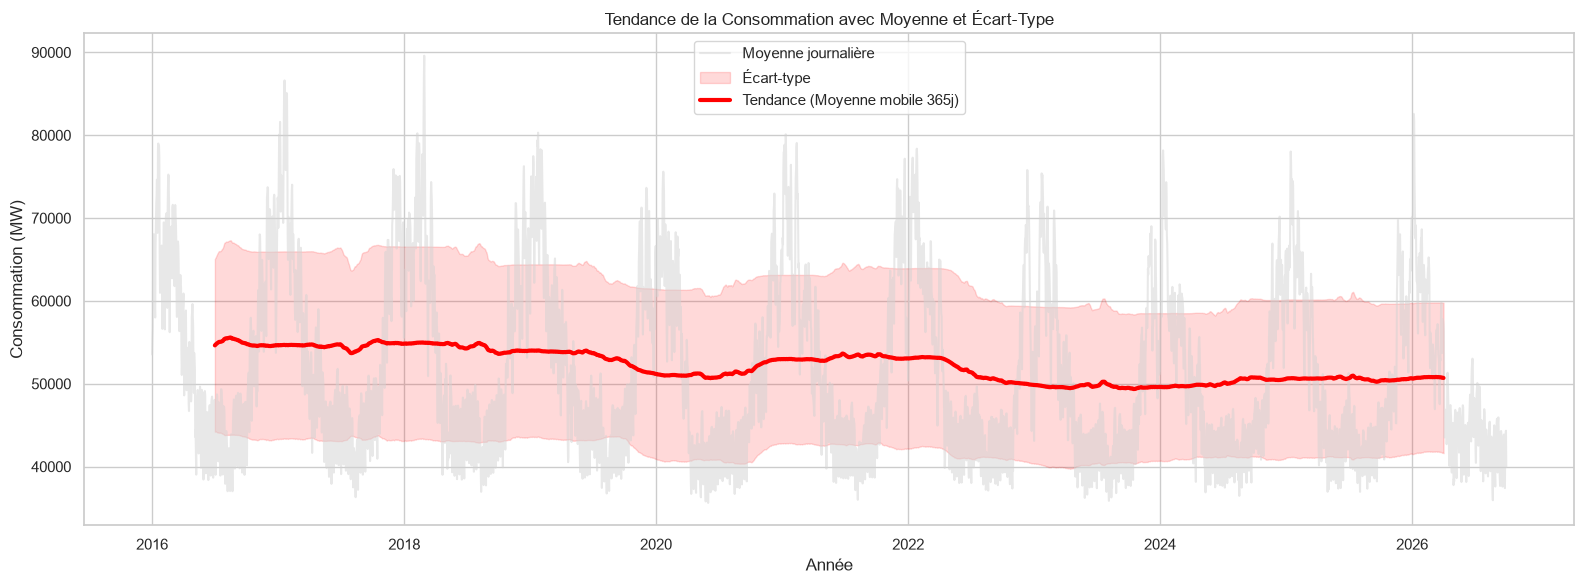

In [323]:
plt.figure(figsize=(16, 6))
df_daily = df.groupby(df['timestamp_paris'].dt.date)['consommation_mw'].mean().reset_index()

df_daily['moyenne_mobile_365j'] = df_daily['consommation_mw'].rolling(window=365, center=True).mean()
df_daily['ecart_type_365j'] = df_daily['consommation_mw'].rolling(window=365, center=True).std()
df_daily['bande_haute'] = df_daily['moyenne_mobile_365j'] + df_daily['ecart_type_365j']
df_daily['bande_basse'] = df_daily['moyenne_mobile_365j'] - df_daily['ecart_type_365j']

sns.lineplot(data=df_daily, x='timestamp_paris', y='consommation_mw', color="lightgray", label="Moyenne journalière", alpha=0.5)

plt.fill_between(
	df_daily['timestamp_paris'], df_daily['bande_basse'], df_daily['bande_haute'], color="red", alpha=0.15, label="Écart-type"
)
sns.lineplot(
	data=df_daily, x='timestamp_paris', y='moyenne_mobile_365j', color="red", linewidth=3, label="Tendance (Moyenne mobile 365j)"
)

plt.title("Tendance de la Consommation avec Moyenne et Écart-Type")
plt.xlabel("Année")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.tight_layout()
plt.show()

Granualité mensuelle :
- Il y a une saisonalité anuuelle,
- Il y a pas de tendance annuelle => Abres. 

Granualité annuelle :
- Pas saisonalité, tendance ou cycle => Abres.
- Consommation avant Covid != Consommation pendant Covid != Consommation après Covid (moyenne et écart) => Abres peut-être.
- Mais la moyenne et écart après Covid sont stable => SARIMAX.

### 1.2 Cycle Mensuel

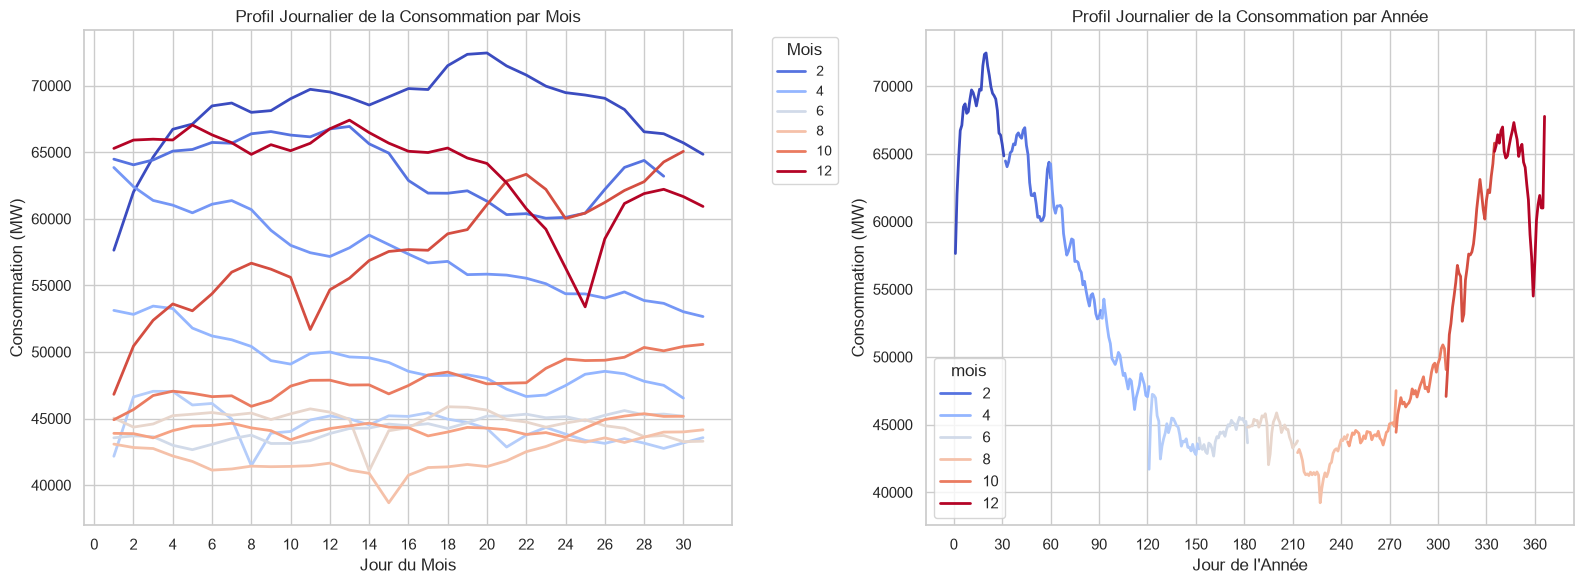

In [347]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df['jour_mois'] = df['timestamp_paris'].dt.day

sns.lineplot(data=df, x='jour_mois', y='consommation_mw', hue='mois', ax=axes[0], palette="coolwarm", errorbar=None, linewidth=2)
axes[0].set_title("Profil Journalier de la Consommation par Mois")
axes[0].set_xlabel("Jour du Mois")
axes[0].set_xticks(range(0, 32, 2))
axes[0].set_ylabel("Consommation (MW)")
axes[0].legend(title="Mois", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


sns.lineplot(data=df, x='jour_annee', y='consommation_mw', hue='mois', ax=axes[1], palette="coolwarm", errorbar=None, linewidth=2)
axes[1].set_title("Profil Journalier de la Consommation par Année")
axes[1].set_xlabel("Jour de l'Année")
axes[1].set_xticks(range(0, 366, 30))
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

Granualité journalière :
- Il y a pas de tendance, cycle, ou saisonalité mensuelle.
- Il y a des trous à des vacances.

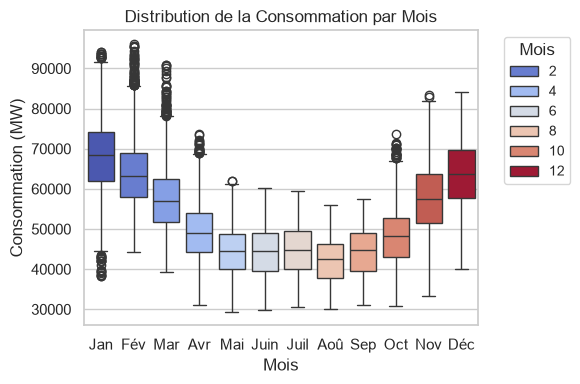

In [354]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))

sns.boxplot(data=df, x='mois', y='consommation_mw', ax=axes, hue='mois', palette="coolwarm")
axes.set_title("Distribution de la Consommation par Mois")
axes.set_xlabel("Mois")
axes.set_xticks(range(12))
axes.set_xticklabels(MOIS)
axes.set_ylabel("Consommation (MW)")
axes.legend(title="Mois", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

### 1.3 Cycle Hebdomadaire

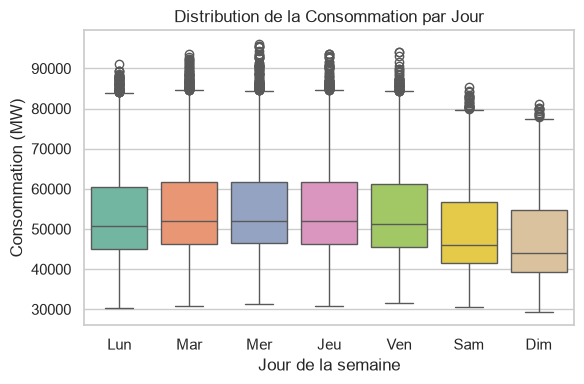

In [355]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))

sns.boxplot(data=df, x='jour_semaine', y='consommation_mw', ax=axes, hue='jour_semaine', palette="Set2", legend=False)
axes.set_title("Distribution de la Consommation par Jour")
axes.set_xlabel("Jour de la semaine")
axes.set_xticks(range(7))
axes.set_xticklabels(JOURS_SEMAINE)
axes.set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

Granualité journalière :
- Il y une saisonnalité hebdomadaire.

### 1.4 Cycle Journalier

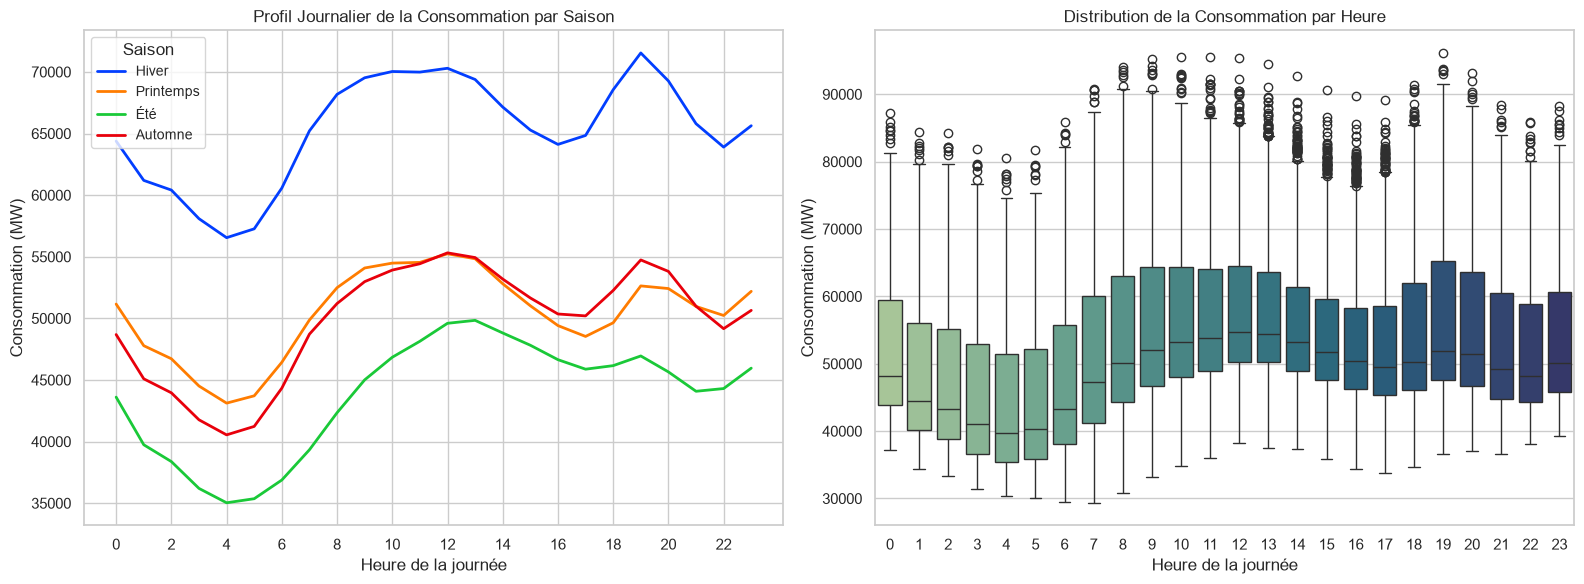

In [360]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=df, x='heure', y='consommation_mw', hue='saison', ax=axes[0], palette="bright", errorbar=None, linewidth=2)
axes[0].set_title("Profil Journalier de la Consommation par Saison")
axes[0].legend(title="Saison", loc='upper left', fontsize='small')
axes[0].set_xlabel("Heure de la journée")
axes[0].set_ylabel("Consommation (MW)")
axes[0].set_xticks(range(0, 24, 2))

sns.boxplot(data=df, x='heure', y='consommation_mw', ax=axes[1], hue='heure', palette="crest", legend=False)
axes[1].set_title("Distribution de la Consommation par Heure")
axes[1].set_xlabel("Heure de la journée")
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

Granualité horaire :
- Il y a pas de tendance journalière => Bon pour les abres.
- Il y a une saisonalité journalière.

### 1.5. Conclusion
- Il y a pas de tendance ou de cycle.
- Il y a des saisonalité annuelle, hebdomadaire, et journalière.
- Il y a pas de l'amplitude.
- La Covid a un impact, après et avant sont différent.

## 2. Relation avec la Météo

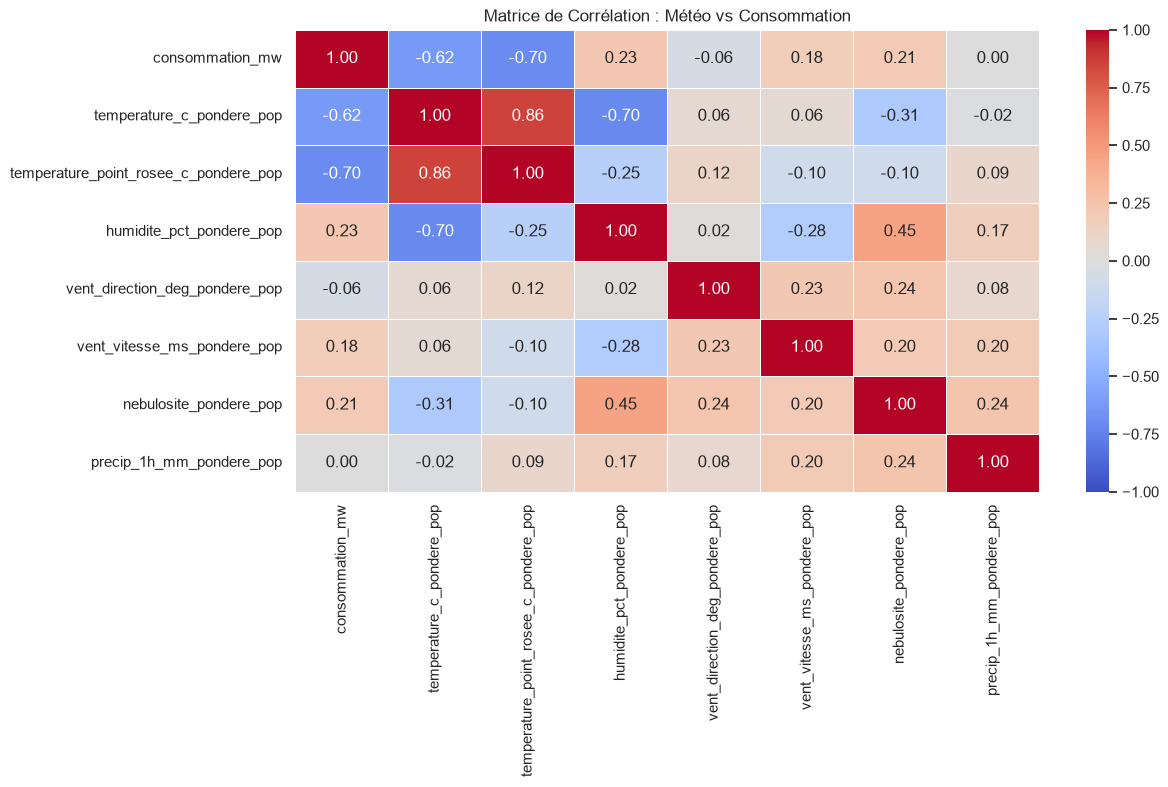

In [370]:
cols_meteo = [
    c for c in df.columns
    if ('temperature' in c or 'humidite' in c or 'vent' in c or 'nebulosite' in c or 'precip' in c) and 'pondere_pop' in c
]

cols_corr = ['consommation_mw'] + cols_meteo
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Matrice de Corrélation : Météo vs Consommation")
plt.show()

- `temperature_c_pondere_pop` et `temperature_point_rosee_c_pondere_pop` sont bons.
- Mais ils sont très corrélés donc on enlève `temperature_c_pondere_pop` et `humidite` aussi.
- Mais il faut tester aussi les autres (sauf `vent_direction`).

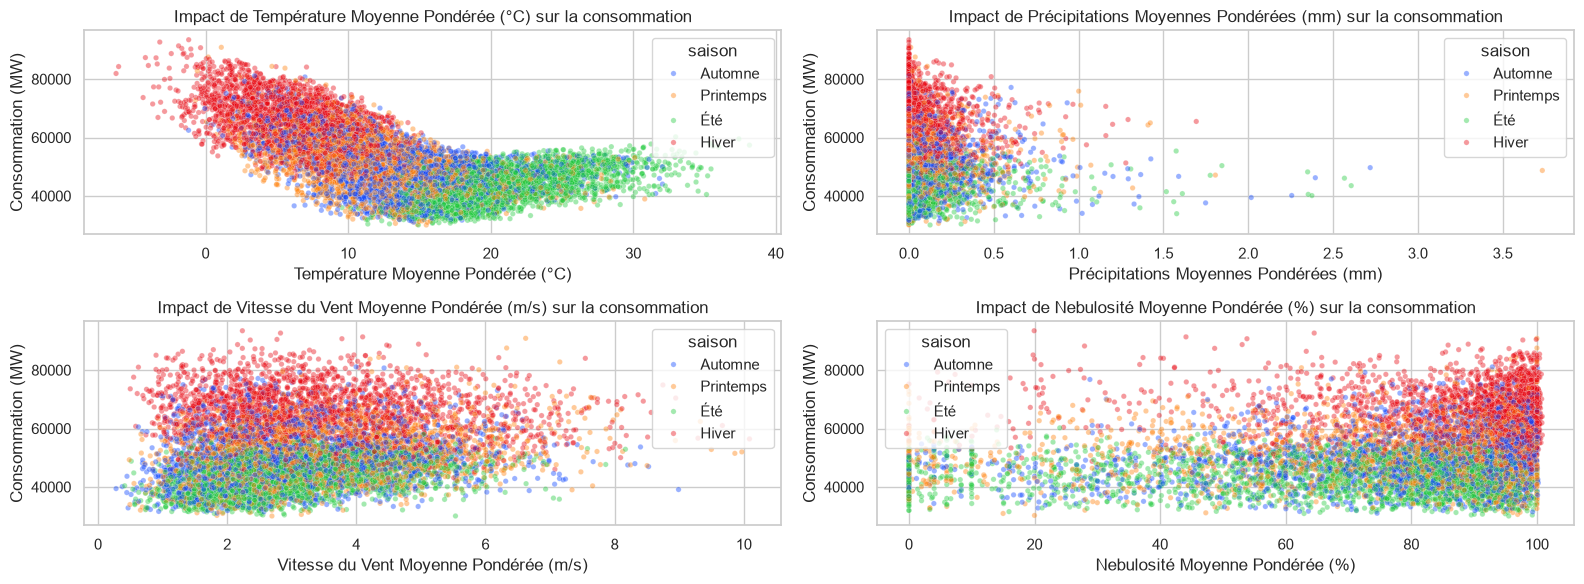

In [373]:
fig, axes = plt.subplots(2, 2, figsize=(16, 6))

variables = [
	("temperature_c_pondere_pop", "Température Moyenne Pondérée (°C)"),
    ("precip_1h_mm_pondere_pop", "Précipitations Moyennes Pondérées (mm)"),
    ("vent_vitesse_ms_pondere_pop", "Vitesse du Vent Moyenne Pondérée (m/s)"),
    ("nebulosite_pondere_pop", "Nebulosité Moyenne Pondérée (%)"),
]

for ax, (column, label) in zip(axes.flat, variables):
    sns.scatterplot(
        data=df.sample(frac=0.1, random_state=42),
        x=column,
        y="consommation_mw",
        hue="saison",
        alpha=0.4,
        s=15,
        palette="bright",
        ax=ax
    )

    ax.set_title(f"Impact de {label} sur la consommation")
    ax.set_xlabel(label)
    ax.set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

## 3. Effets Calendaires (Fériés & Vacances)

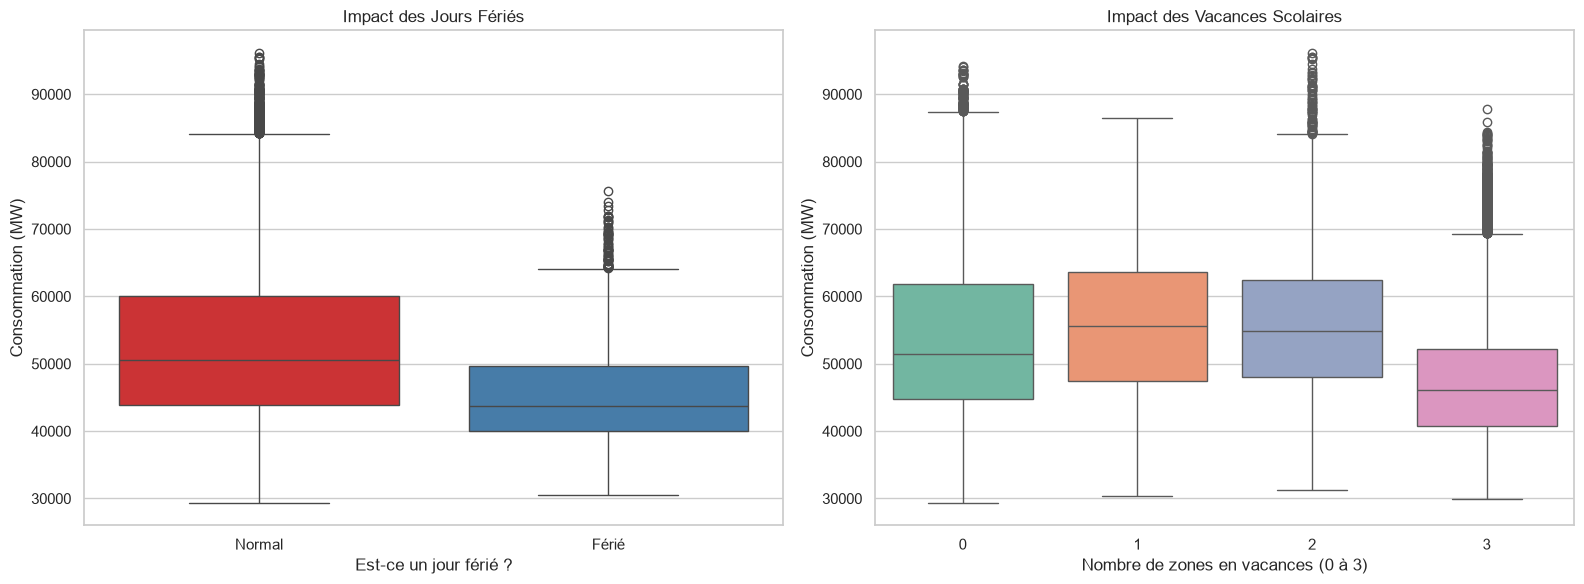

In [375]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='ferie', y='consommation_mw', ax=axes[0], hue='ferie', palette="Set1", legend=False)
axes[0].set_title("Impact des Jours Fériés")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Férié'])
axes[0].set_xlabel("Est-ce un jour férié ?")
axes[0].set_ylabel("Consommation (MW)")

sns.boxplot(data=df, x='vacances', y='consommation_mw', ax=axes[1], hue='vacances', palette="Set2", legend=False)
axes[1].set_title("Impact des Vacances Scolaires")
axes[1].set_xlabel("Nombre de zones en vacances (0 à 3)")
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

## 4. Impact de la COVID

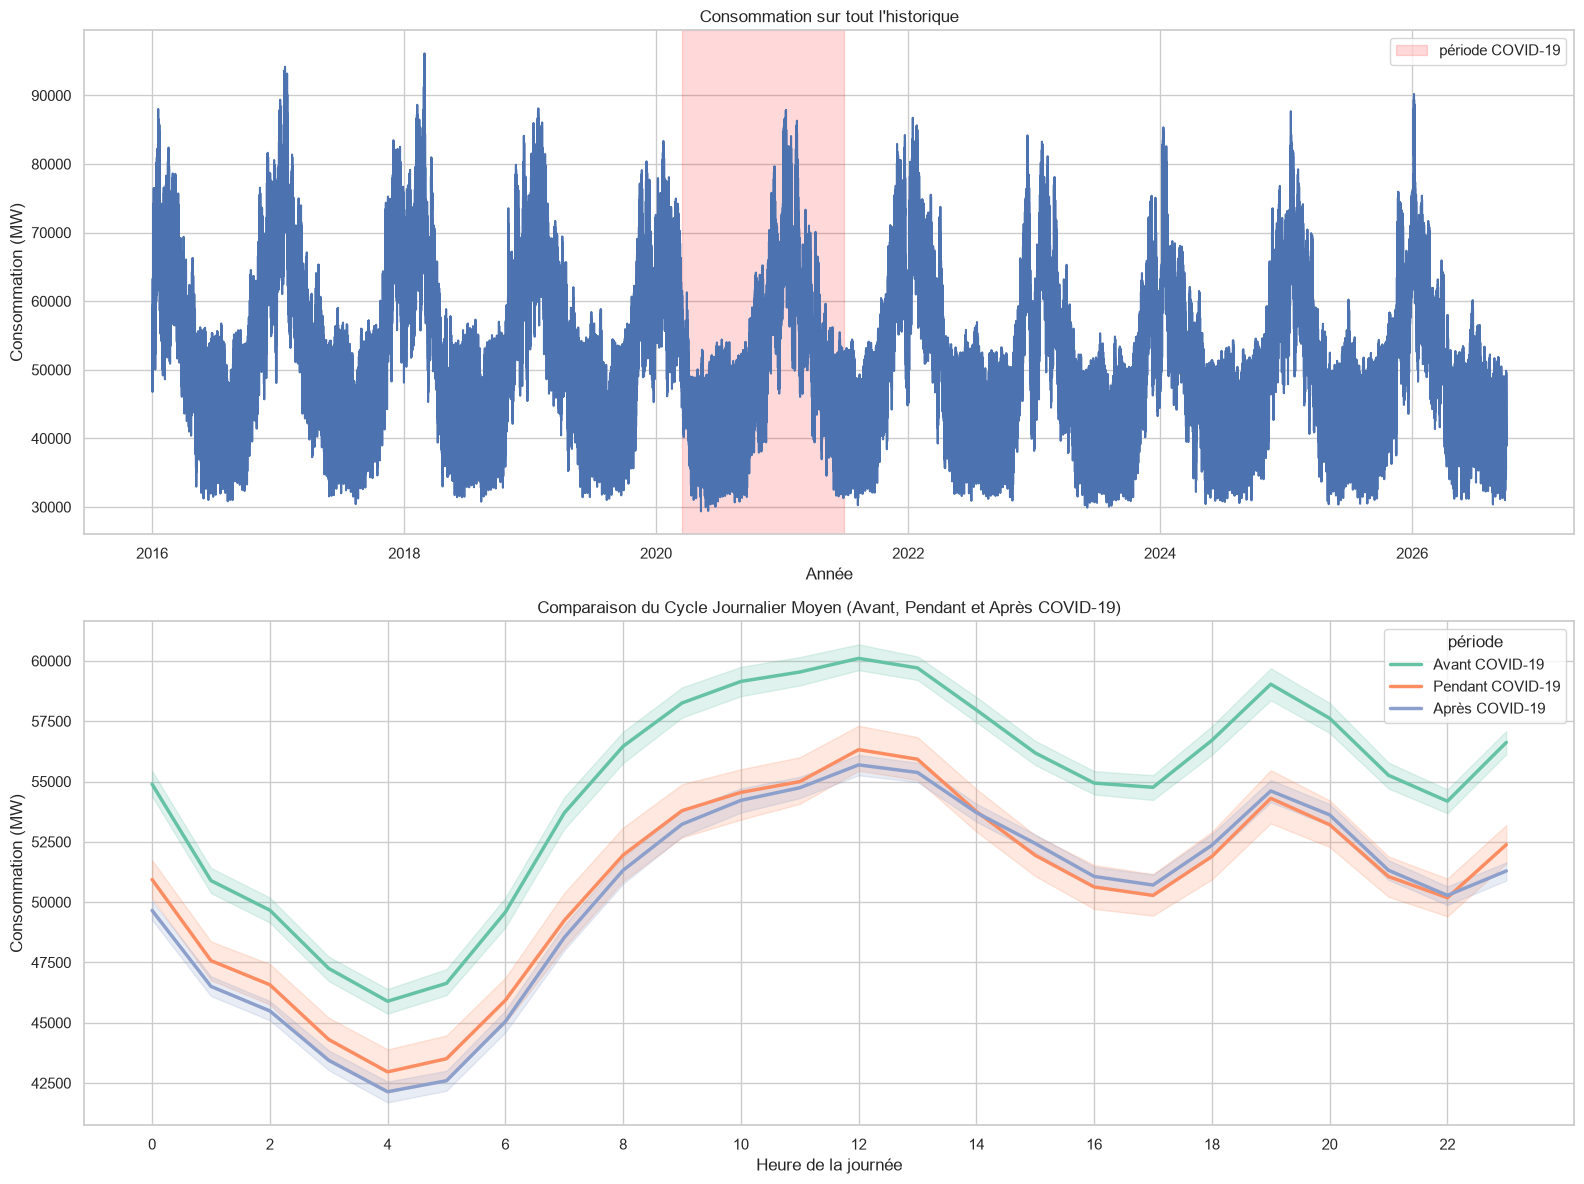

In [395]:
start_covid = df.loc[df['covid19'] == 1, 'timestamp_paris'].min()
end_covid = df.loc[df['covid19'] == 1, 'timestamp_paris'].max()

df_compare = df.copy()
df_compare['période'] = 'Pendant COVID-19'
df_compare.loc[df_compare['timestamp_paris'] < start_covid, 'période'] = 'Avant COVID-19'
df_compare.loc[df_compare['timestamp_paris'] > end_covid, 'période'] = 'Après COVID-19'

ordre_periodes = ['Avant COVID-19', 'Pendant COVID-19', 'Après COVID-19']

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

sns.lineplot(data=df, x='timestamp_paris', y='consommation_mw', ax=axes[0])
axes[0].axvspan(
	start_covid.tz_localize(None), end_covid.tz_localize(None), color='red', alpha=0.15, label='période COVID-19'
)
axes[0].set_title("Consommation sur tout l'historique")
axes[0].set_ylabel("Consommation (MW)")
axes[0].set_xlabel("Année")
axes[0].legend()

sns.lineplot(
	data=df_compare, x='heure', y='consommation_mw',
	hue='période', hue_order=ordre_periodes, ax=axes[1], palette="Set2", linewidth=2.5
)
axes[1].set_title("Comparaison du Cycle Journalier Moyen (Avant, Pendant et Après COVID-19)")
axes[1].set_xlabel("Heure de la journée")
axes[1].set_ylabel("Consommation (MW)")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

## 5. Analyse des Retards (Autocorrélation)

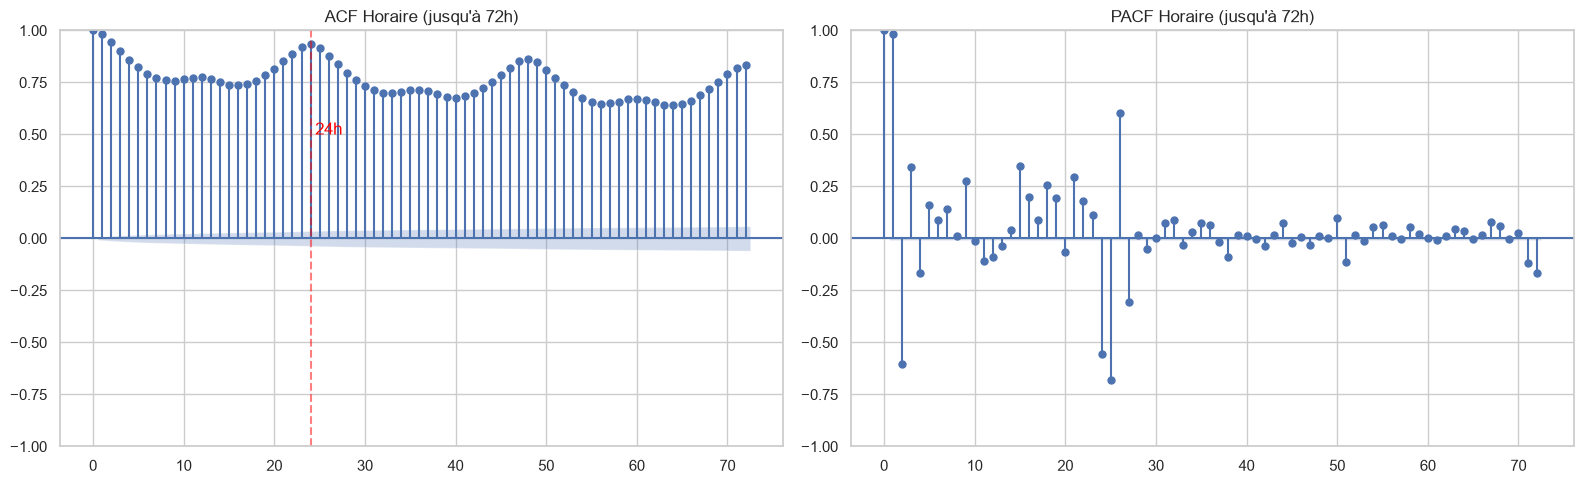

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(df['consommation_mw'].dropna(), lags=72, ax=axes[0], title="ACF Horaire (jusqu'à 72h)")
plot_pacf(df['consommation_mw'].dropna(), lags=72, ax=axes[1], title="PACF Horaire (jusqu'à 72h)")

axes[0].axvline(x=24, color='red', linestyle='--', alpha=0.5)
axes[0].text(24.5, 0.5, '24h', color='red')

plt.tight_layout()
plt.show()

tendance?
Remarque : La PACF montre un pic massif à 1h, et un rebond très net à 24h. Le modèle a besoin de la consommation de la veille à la même heure !

### Autocorrélation Journalière (Saisonnalité longue)
Pour mieux voir les cycles de la semaine et de l'année, nous faisons la moyenne journalière avant d'appliquer l'ACF.

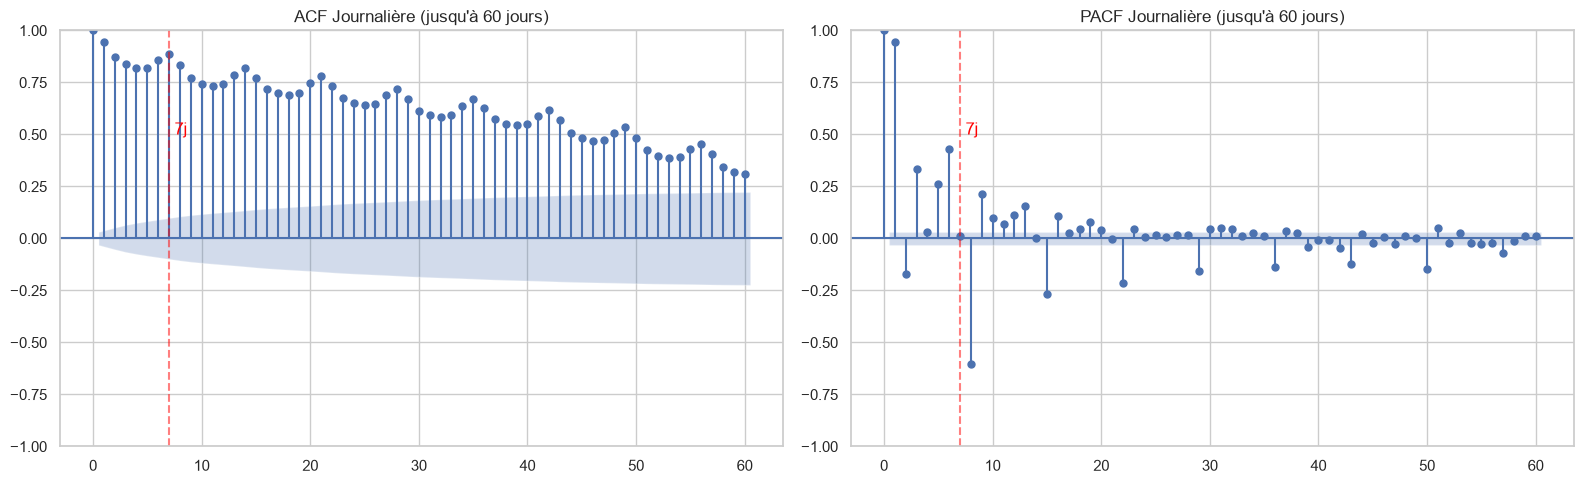

In [393]:
# 2. Échelle Journalière (Lags jusqu'à 400 jours)
df_daily = df.groupby(df['timestamp_paris'].dt.date)['consommation_mw'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# PACF sur 30 jours (car au-delà, les corrélations s'estompent)
plot_acf(df_daily.dropna(), lags=60, ax=axes[0], title="ACF Journalière (jusqu'à 60 jours)")
axes[0].axvline(x=7, color='red', linestyle='--', alpha=0.5)
axes[0].text(7.5, 0.5, '7j', color='red')

# PACF sur 30 jours (car au-delà, les corrélations directes partielles s'estompent)
plot_pacf(df_daily.dropna(), lags=60, ax=axes[1], title="PACF Journalière (jusqu'à 60 jours)")
axes[1].axvline(x=7, color='red', linestyle='--', alpha=0.5)
axes[1].text(7.5, 0.5, '7j', color='red')

plt.tight_layout()
plt.show()

Remarque :
L'ACF prouve qu'un an après (365 jours), la ressemblance remonte fortement (Saisonnalité annuelle).
La PACF montre un effet direct fort à 7 jours. Le modèle doit ABSOLUMENT connaître la consommation d'il y a 1 semaine exacte (J-7).

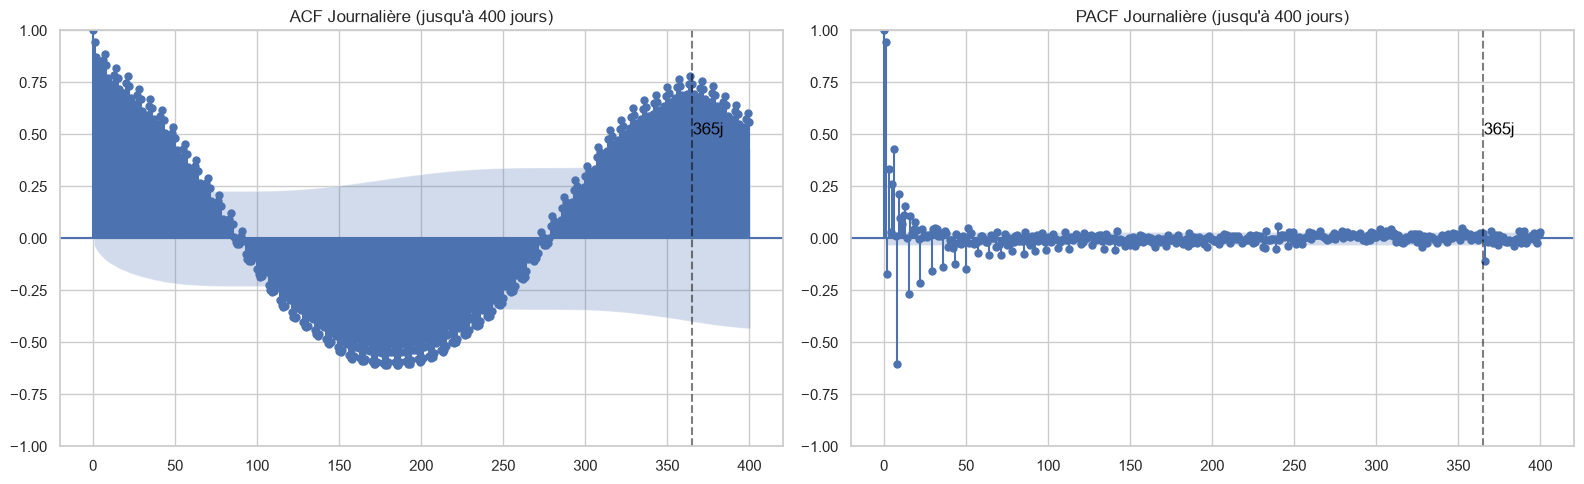

In [392]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF sur 400 jours (pour voir le cycle annuel de 365 jours)
plot_acf(df_daily.dropna(), lags=400, ax=axes[0], title="ACF Journalière (jusqu'à 400 jours)")
axes[0].axvline(x=365, color='black', linestyle='--', alpha=0.5)
axes[0].text(365.5, 0.5, '365j', color='black')

# PACF sur 400 jours (pour voir le cycle annuel de 365 jours)
plot_pacf(df_daily.dropna(), lags=400, ax=axes[1], title="PACF Journalière (jusqu'à 400 jours)")
axes[1].axvline(x=365, color='black', linestyle='--', alpha=0.5)
axes[1].text(365.5, 0.5, '365j', color='black')

plt.tight_layout()
plt.show()

STL?

## Conclusion

La série présente . . .
Je soupçonne une saisonnalité de période . . .parce que . . .
L’ACF montre . . .
La PACF suggère que . . .
Avant de la modéliser, je voudrais vérifier / transformer . . .



Employer correctement : fréquence, période, retard, horizon, tendance, saisonnalité,
cycle, résidu.
Expliquer pourquoi l’ordre temporel contient de l’information.
Choisir entre une lecture additive et multiplicative simple.
Expliquer le rôle d’une moyenne mobile et d’une décomposition.
Définir et interpréter l’ACF.
Reconnaître persistance, saisonnalité et faible mémoire dans un corrélogramme.
Expliquer l’idée de la PACF sans recourir à une recette de choix de modèle.





Ali
SARIMAX => modifié/limites

Asma
XGBoost => Bon
- Feature engineering C[J], C[J-7], C[J-365], C[J-366], T[J], T[J-7],...
LSTM => Bon, T[J, <=14h], T[J-1], T[J-7], T[J-365], T[J-366]

Dang
References
Prophet par Meta
Regression => Linear / Fourier.